In [33]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sb 
 

dataset = pd.read_excel("Dataset/HousePricePrediction.xlsx")
print(dataset.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [34]:
dataset.shape

(2919, 13)

In [35]:
obj = (dataset.dtypes == "object")
object_cols = list(obj[obj].index)
print("Categorical avriables: ", len(object_cols))

int_ = (dataset.dtypes == "int")
num_cols = list(int_[int_].index)
print("Integer variable: ", len(num_cols))

f1 = (dataset.dtypes == "float")
f1_cols = list(f1[f1].index)
print("Float variable: ", len(f1_cols))

Categorical avriables:  4
Integer variable:  6
Float variable:  3


<Axes: >

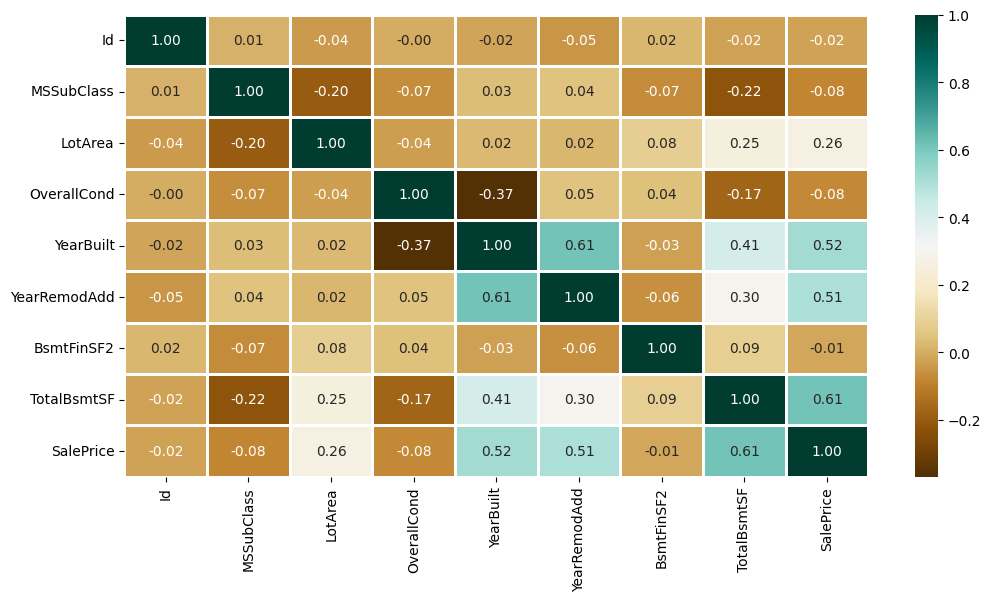

In [36]:
numerical_dataset =  dataset.select_dtypes(include = ["number"])

plt.figure(figsize = (12, 6))
sb.heatmap(numerical_dataset.corr(),
            cmap = "BrBG",
            fmt = ".2f",
            linewidths = 2,
            annot = True)

<Axes: title={'center': 'No. Unique values of Categorical Features'}>

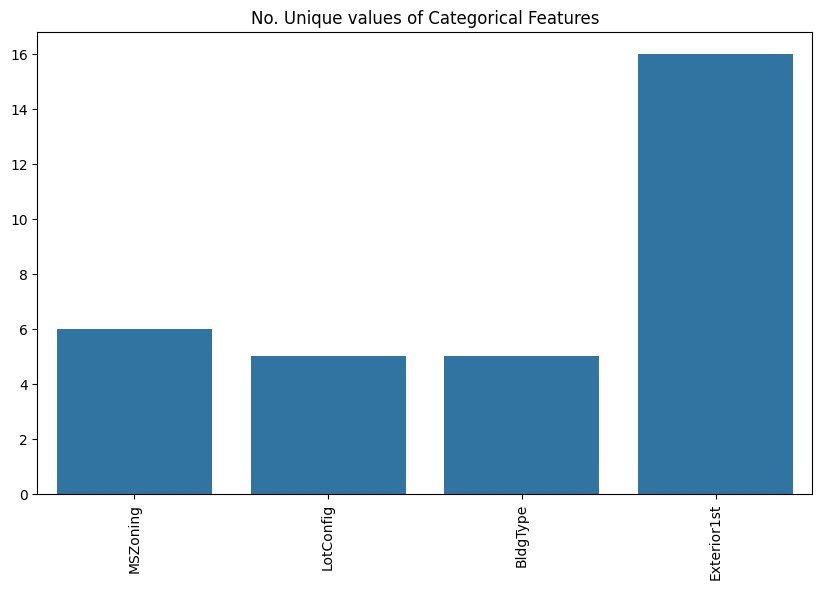

In [37]:
unique_values = []
for col in object_cols:
    unique_values.append(dataset[col].unique().size)
plt.figure(figsize = (10, 6))
plt.title("No. Unique values of Categorical Features")
plt.xticks(rotation = 90)
sb.barplot(x = object_cols, y = unique_values)
# use line down to add some color in barplot
# sb.barplot(x = object_cols, y = unique_values, palette=['blue', 'orange', 'green', 'red'])


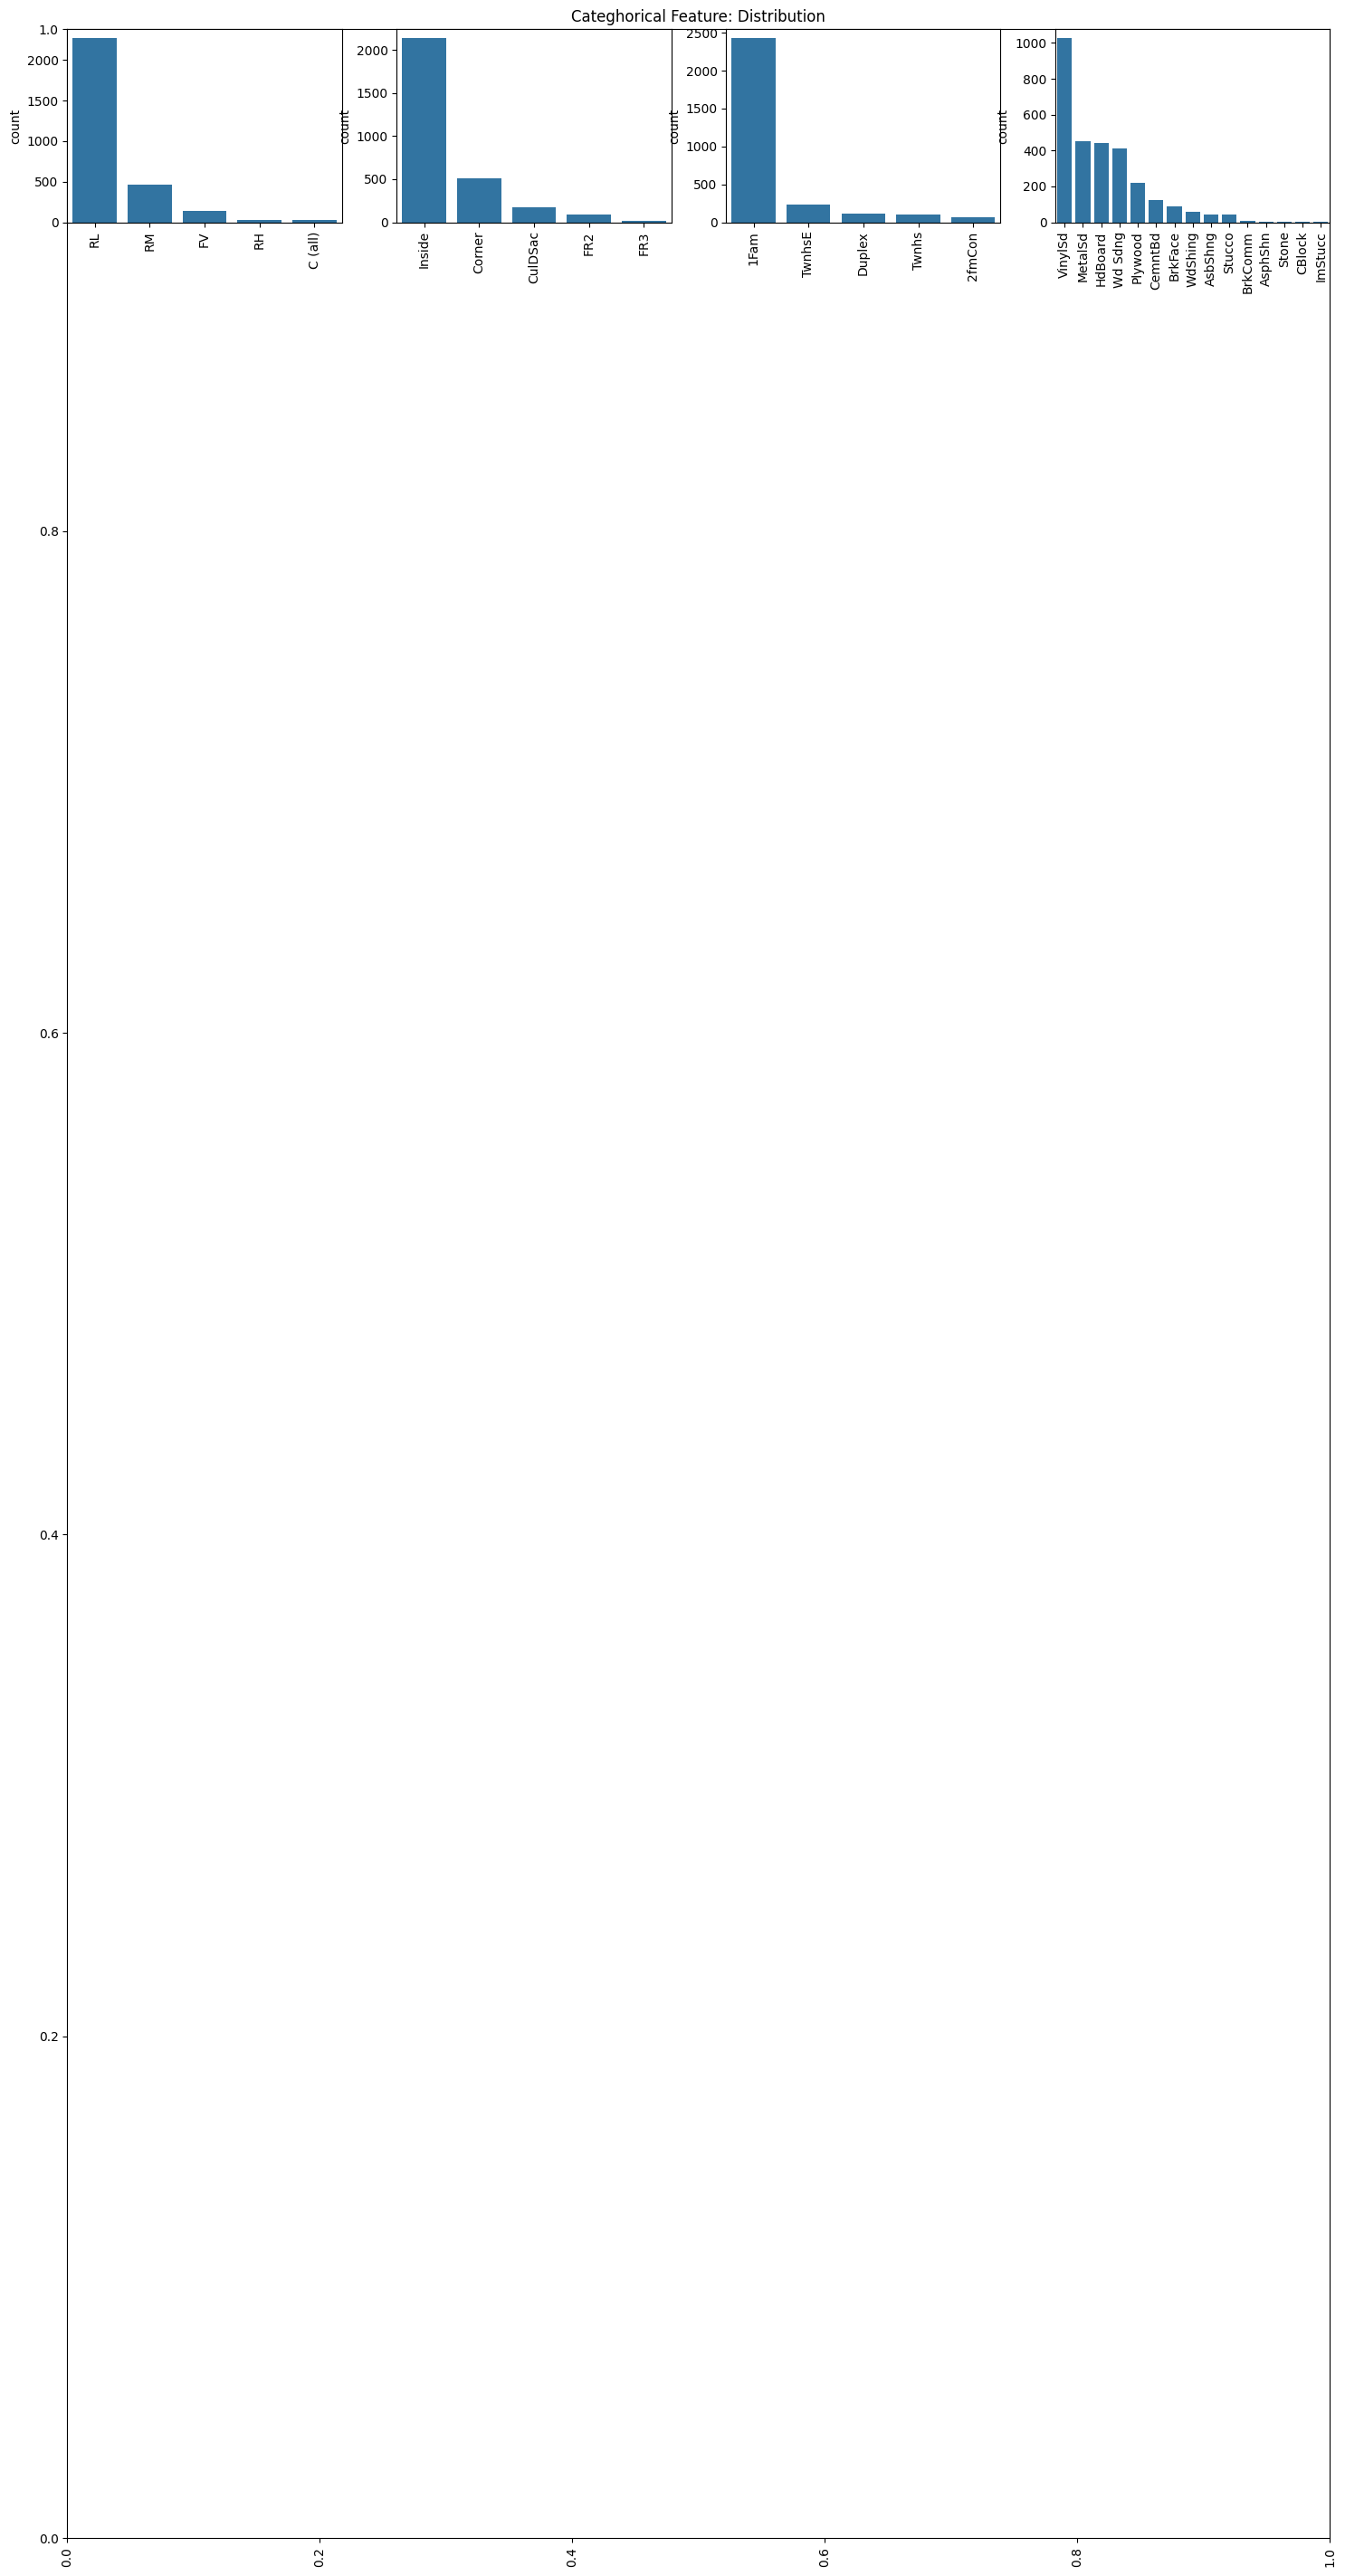

In [38]:
plt.figure(figsize = (18, 36))
plt.title("Categhorical Feature: Distribution")
plt.xticks(rotation = 90)
index = 1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation = 90)
    sb.barplot(x = list(y.index), y = y)
    index += 1

In [39]:
dataset.drop(["Id"], 
            axis = 1,
            inplace = True)

In [40]:
dataset["SalePrice"] = dataset["SalePrice"].fillna(dataset["SalePrice"].mean())

In [41]:
new_dataset = dataset.dropna()

In [42]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [45]:
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == "object")
object_cols = list(s[s].index)
print("Categorical variables: ")
print(object_cols)
print("No. of. categorical features: ", len(object_cols))

Categorical variables: 
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


In [57]:
OH_encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis = 1)
df_final = pd.concat([df_final, OH_cols], axis = 1)